In [1]:
!git clone https://github.com/kapitan05/causal_calibration.git

fatal: destination path 'causal_calibration' already exists and is not an empty directory.


In [2]:
%cd causal_calibration/

/content/causal_calibration


In [3]:
!pip install captum

In [4]:
import urllib.request
import torch
import matplotlib.pyplot as plt
from PIL import Image

from src.models import load_models, get_preprocessing_transforms
from src.attribution import AttributionPipeline
from src.causal_tests import evaluate_causal_metric
from src.visualize_tests import visualize_tests

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

models_dict = load_models(device)
resnet = models_dict["resnet50"]
vit = models_dict["vit_b_16"]

preprocess = get_preprocessing_transforms()

cuda
Pobieranie wag modelu ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 146MB/s]


Pobieranie wag modelu ViT-B/16...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 73.6MB/s]


Detected 1 with probabaility of 49.3%


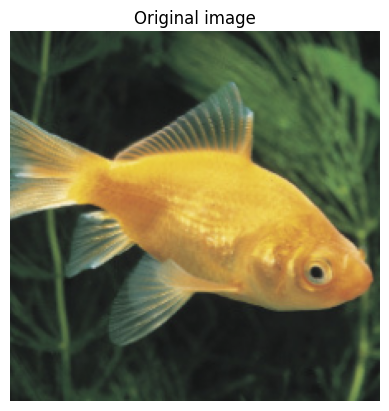

In [6]:
url = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01443537_goldfish.JPEG"
image_path = "goldfish.jpg"
urllib.request.urlretrieve(url, image_path)

img_pil = Image.open(image_path).convert("RGB")
input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    initial_logits = resnet(input_tensor)
    initial_probs = torch.nn.functional.softmax(initial_logits, dim=1)[0]

    TARGET_CLASS = torch.argmax(initial_probs).item()
    top_prob = initial_probs[TARGET_CLASS].item()

print(f"Detected {TARGET_CLASS} with probabaility of {top_prob*100:.1f}%")

# disply image
img_display = input_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
img_display = std * img_display + mean
img_display = img_display.clip(0, 1)

plt.imshow(img_display)
plt.title("Original image")
plt.axis("off")
plt.show()

Generowanie mapy IG dla ResNet50...


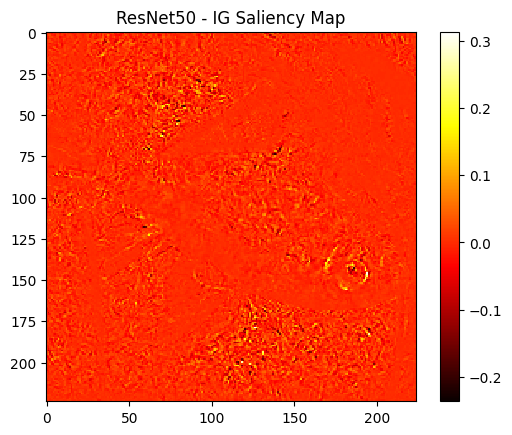

In [7]:
# occlusion takes 5 minutes on GPU
resnet_explainer = AttributionPipeline(resnet)
method_name = "ig"

print(f"Generowanie mapy {method_name.upper()} dla ResNet50...")
saliency_map_resnet = resnet_explainer.generate_map(input_tensor, TARGET_CLASS, method_name)

plt.imshow(saliency_map_resnet.numpy(), cmap='hot', interpolation='nearest')
plt.title(f"ResNet50 - {method_name.upper()} Saliency Map")
plt.colorbar()
plt.show()

Deletion...
Insertion...


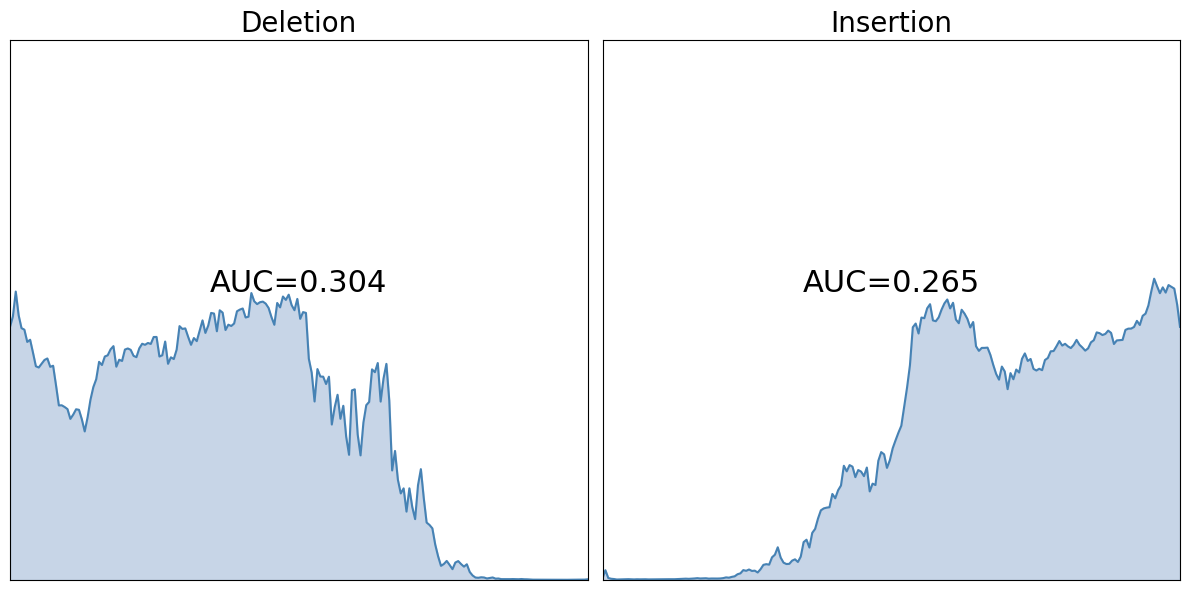

In [8]:
step_frac = 0.005

print("Deletion...")
del_probs, del_auc = evaluate_causal_metric(
    model=resnet,
    image=input_tensor,
    saliency_map=saliency_map_resnet.to(device),
    target_class=TARGET_CLASS,
    mode="deletion",
    step_fraction=step_frac,
    batch_size=16
)

print("Insertion...")
ins_probs, ins_auc = evaluate_causal_metric(
    model=resnet,
    image=input_tensor,
    saliency_map=saliency_map_resnet.to(device),
    target_class=TARGET_CLASS,
    mode="insertion",
    step_fraction=step_frac,
    batch_size=16
)

visualize_tests(step_frac, del_probs, ins_probs, del_auc, ins_auc)

Detected 45 with probabaility of 49.1%


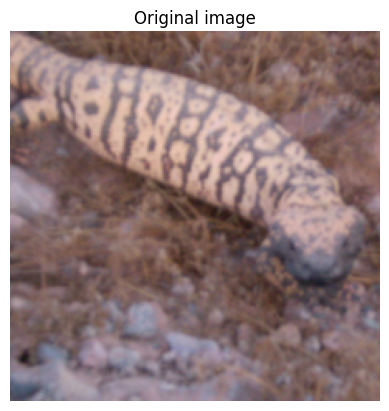

In [9]:
url = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01692333_Gila_monster.JPEG"
image_path = "gilla_monster.jpg"
urllib.request.urlretrieve(url, image_path)

img_pil = Image.open(image_path).convert("RGB")
input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    initial_logits = resnet(input_tensor)
    initial_probs = torch.nn.functional.softmax(initial_logits, dim=1)[0]

    TARGET_CLASS = torch.argmax(initial_probs).item()
    top_prob = initial_probs[TARGET_CLASS].item()

print(f"Detected {TARGET_CLASS} with probabaility of {top_prob*100:.1f}%")

# disply image
img_display = input_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
img_display = std * img_display + mean
img_display = img_display.clip(0, 1)

plt.imshow(img_display)
plt.title("Original image")
plt.axis("off")
plt.show()

Attribution Map SALIENCY for ViT...


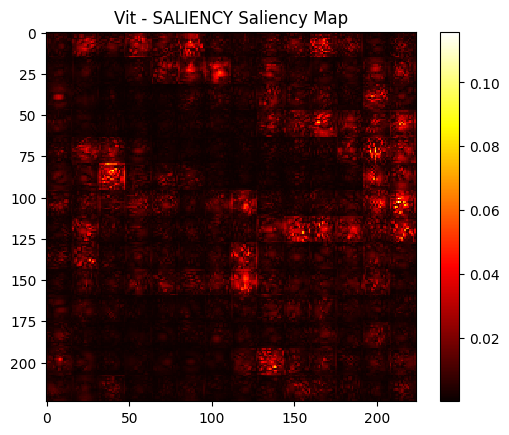

In [11]:
# occlusion takes 5 minutes on GPU
vit_explainer = AttributionPipeline(vit)
method_name = "saliency"

print(f"Attribution Map {method_name.upper()} for ViT...")
saliency_map_vit = vit_explainer.generate_map(input_tensor, TARGET_CLASS, method_name)

plt.imshow(saliency_map_vit.numpy(), cmap='hot', interpolation='nearest')
plt.title(f"Vit - {method_name.upper()} Saliency Map")
plt.colorbar()
plt.show()

Deletion...
Insertion...


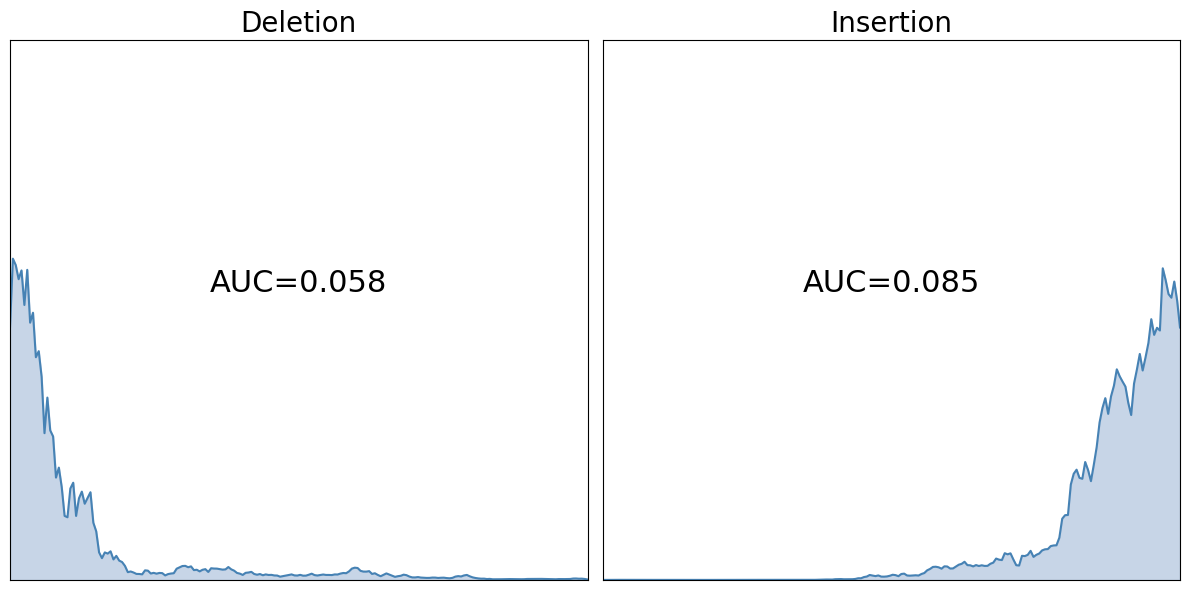

In [12]:
step_frac = 0.005

print("Deletion...")
del_probs, del_auc = evaluate_causal_metric(
    model=resnet,
    image=input_tensor,
    saliency_map=saliency_map_resnet.to(device),
    target_class=TARGET_CLASS,
    mode="deletion",
    step_fraction=step_frac,
    batch_size=16
)

print("Insertion...")
ins_probs, ins_auc = evaluate_causal_metric(
    model=resnet,
    image=input_tensor,
    saliency_map=saliency_map_resnet.to(device),
    target_class=TARGET_CLASS,
    mode="insertion",
    step_fraction=step_frac,
    batch_size=16
)

visualize_tests(step_frac, del_probs, ins_probs, del_auc, ins_auc)